# EDA - Telco Customer Churn

- Objetivo: realizar a análise exploratória do dataset de churn de clientes de telecomunicações, validando estrutura, qualidade dos dados, variável alvo e possíveis relações entre as features e o churn.

## 1. Configuração do Ambiente

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

# Estatística
from scipy import stats


In [59]:
warnings.filterwarnings('ignore')

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
sns.set_palette("deep")

## 2. Carregamento dos Dados

### Sobre o Dataset Telco Customer Churn

Fonte: IBM Sample Dataset disponibilizado no Kaggle.

Dataset:  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Este dataset contém informações de clientes de uma empresa de telecomunicações e tem como objetivo prever se um cliente irá cancelar (churn) ou permanecer com o serviço.

Cada linha representa um cliente e inclui características demográficas, informações de contrato, serviços contratados e dados de faturamento.

- Observações: **7.043 clientes**
- Colunas: **21 variáveis**
- Variável alvo: **Churn (Yes / No)**
- Tipo de problema: **Classificação binária**
- Objetivo: prever a probabilidade de cancelamento de um cliente

O dataset é amplamente utilizado em estudos de **Customer Churn Prediction**, sendo um exemplo clássico de aplicação de Machine Learning em retenção de clientes.

---

### Colunas do Dataset

customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn

---

### Esquema das Variáveis

#### Identificação

- **customerID**: identificador único do cliente

---

#### Características demográficas

- **gender**: gênero do cliente (Male / Female)
- **SeniorCitizen**: indica se o cliente é idoso (1 = sim, 0 = não)
- **Partner**: indica se o cliente possui parceiro(a) (Yes / No)
- **Dependents**: indica se o cliente possui dependentes (Yes / No)

---

#### Informações de relacionamento com a empresa

- **tenure**: tempo de permanência do cliente na empresa (em meses)

---

#### Serviços contratados

- **PhoneService**: serviço de telefone contratado
- **MultipleLines**: múltiplas linhas telefônicas
- **InternetService**: tipo de serviço de internet (DSL, Fiber optic ou No)
- **OnlineSecurity**: serviço de segurança online
- **OnlineBackup**: serviço de backup online
- **DeviceProtection**: proteção de dispositivos
- **TechSupport**: suporte técnico
- **StreamingTV**: serviço de streaming de TV
- **StreamingMovies**: serviço de streaming de filmes

---

#### Informações de contrato e pagamento

- **Contract**: tipo de contrato (Month-to-month, One year, Two year)
- **PaperlessBilling**: faturamento eletrônico (Yes / No)
- **PaymentMethod**: método de pagamento do cliente

---

#### Informações financeiras

- **MonthlyCharges**: valor mensal cobrado do cliente
- **TotalCharges**: valor total pago pelo cliente durante o período de contrato

---

#### Variável alvo

- **Churn**: indica se o cliente cancelou o serviço  
  - **Yes** → cliente cancelou  
  - **No** → cliente permaneceu

---

### Objetivo da Análise

Nesta etapa será realizada uma **Análise Exploratória de Dados (EDA)** com os seguintes objetivos:

- compreender a estrutura do dataset
- identificar possíveis inconsistências ou valores ausentes
- analisar a distribuição da variável alvo (**Churn**)
- explorar relações entre variáveis e o churn
- identificar padrões que possam auxiliar na construção de modelos preditivos

Essas análises auxiliam na preparação dos dados e na construção de modelos de **Machine Learning** para prever o cancelamento de clientes.

In [60]:
# Caminho do dataset
path = "../data/raw/telco_customer_churn.csv"

# Carregar os dados
df = pd.read_csv(path)

# Verificar dimensão do dataset
print(f"Shape dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")

# Visualizar as primeiras linhas
df.head(10)

Shape dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


O dataset carregado contém informações sobre clientes de uma empresa de telecomunicações, incluindo características demográficas, serviços contratados, informações de pagamento e dados de faturamento.

Cada linha representa um cliente, com variáveis como gênero, tempo de permanência na empresa (tenure), tipo de contrato, serviços adicionais contratados e valores cobrados mensalmente.

A variável alvo (target) do problema é **Churn**, que indica se o cliente cancelou ou não o serviço.

O objetivo da análise é identificar padrões e relações entre as variáveis disponíveis e o churn dos clientes, utilizando técnicas de **Análise Exploratória de Dados (EDA)** para compreender a estrutura do dataset, verificar a qualidade dos dados e preparar as variáveis para etapas posteriores de modelagem preditiva.

## 3. Inspeção Inicial dos Dados

In [61]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
df.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()


=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Análise Exploratória de Dados (EDA)

Nesta etapa será realizada a Análise Exploratória de Dados (EDA) com o objetivo de investigar a qualidade do dataset, identificar possíveis inconsistências, analisar a distribuição da variável alvo e compreender relações relevantes entre as variáveis explicativas e o churn.

A EDA é uma etapa fundamental em projetos de Machine Learning, pois permite entender melhor o comportamento dos dados antes da construção dos modelos preditivos.

### 4.1 Verificação de Valores Ausentes (Missing Values)

Nesta etapa será analisada a presença de valores ausentes no dataset (strings vazias) e também de valores nulos tradicionais (`NaN`).


In [62]:
print("=== ANÁLISE DE VALORES AUSENTES ===\n")

# Contagem
null_values = df.isnull().sum()
empty_values = (df == " ").sum()

# Criar dataframe
missing_summary = pd.DataFrame({
    "Valores_Nulos": null_values,
    "Strings_Vazias": empty_values
})

missing_summary["Total_Ausentes"] = missing_summary["Valores_Nulos"] + missing_summary["Strings_Vazias"]
missing_summary["Percentual (%)"] = (missing_summary["Total_Ausentes"] / len(df) * 100).round(2)

missing_summary = missing_summary.sort_values(by="Total_Ausentes", ascending=False)

# Mostrar tabela
display(
    missing_summary.style.background_gradient(
        cmap="Reds",
        subset=["Valores_Nulos","Strings_Vazias","Total_Ausentes","Percentual (%)"]
    )
)

# Filtrar apenas colunas com problema
missing_values = missing_summary[missing_summary["Total_Ausentes"] > 0]

if len(missing_values) > 1:

    plt.figure(figsize=(10,6))
    plt.barh(
        missing_values.index,
        missing_values["Percentual (%)"]
    )

    plt.xlabel("Porcentagem de valores ausentes (%)")
    plt.title("Distribuição de Valores Ausentes por Coluna")
    plt.tight_layout()
    plt.show()

elif len(missing_values) == 1:
    print("Apenas uma coluna apresenta valores ausentes:")
    display(missing_values)

else:
    print("Nenhum valor ausente detectado.")

=== ANÁLISE DE VALORES AUSENTES ===



,Valores_Nulos,Strings_Vazias,Total_Ausentes,Percentual (%)
TotalCharges,0,11,11,0.160000
customerID,0,0,0,0.000000
DeviceProtection,0,0,0,0.000000
MonthlyCharges,0,0,0,0.000000
PaymentMethod,0,0,0,0.000000
PaperlessBilling,0,0,0,0.000000
Contract,0,0,0,0.000000
StreamingMovies,0,0,0,0.000000
StreamingTV,0,0,0,0.000000
TechSupport,0,0,0,0.000000


Apenas uma coluna apresenta valores ausentes:


,Valores_Nulos,Strings_Vazias,Total_Ausentes,Percentual (%)
TotalCharges,0,11,11,0.16


A verificação inicial mostra que o dataset não apresenta valores nulos. 

Contudo, a coluna **TotalCharges** possui registros com strings vazias, notadamente presente em clientes recém cadastrados que ainda não acumularam cobrança total.

Devido à baixa proporção desses registros (0,16%), o impacto sobre a análise é limitado, mas a variável será tratada adequadamente antes das etapas de modelagem.





### 4.2 Tipos de Variáveis

Nesta etapa, as variáveis do dataset serão classificadas de acordo com seu tipo de dado, distinguindo variáveis numéricas, categóricas e identificadoras. Essa separação é importante para orientar as análises estatísticas e gráficas, além de facilitar a preparação futura dos dados para modelagem.

Usei o df.nunique para validar valores óbvios de colunas como gender, partners, churn, entre outros.

In [63]:
print("=== TIPOS DE DADOS ===\n")
display(df.dtypes)

print("=== QUANTIDADE DE VALORES ÚNICOS POR COLUNA ===\n")
display(df.nunique())

=== TIPOS DE DADOS ===



customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== QUANTIDADE DE VALORES ÚNICOS POR COLUNA ===



customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [64]:
# Separação inicial das colunas por tipo
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(numeric_cols)

print("\nColunas categóricas:")
print(categorical_cols)

Colunas numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Colunas categóricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


Observa-se que a maior parte das variáveis do dataset é categórica, refletindo características contratuais e serviços contratados pelos clientes. As principais variáveis numéricas são **SeniorCitizen**, **tenure** e **MonthlyCharges**.

A coluna **TotalCharges** aparece inicialmente como categórica (`object`), embora conceitualmente represente um valor monetário e devesse ser numérica. Esse comportamento será investigado na próxima subseção.

### 4.3 Problema da Variável `TotalCharges`

A variável **TotalCharges** representa o valor total pago pelo cliente ao longo do relacionamento com a empresa, sendo portanto uma variável numérica. No entanto, na base carregada ela aparece como texto (`object`).

Conforme detectado anteriormente, esse problema ocorre porque alguns registros contêm valores em branco, o que impede a conversão automática da coluna para formato numérico. Antes prosseguir com as demais análises, faremos o tratamento desses valores para NaN.

In [65]:
print("=== EXEMPLOS DA COLUNA TotalCharges ===\n")
display(df["TotalCharges"].head(10))

=== EXEMPLOS DA COLUNA TotalCharges ===



0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [66]:
print("=== QUANTIDADE DE STRINGS VAZIAS EM TotalCharges ===\n")
print((df["TotalCharges"] == " ").sum())

=== QUANTIDADE DE STRINGS VAZIAS EM TotalCharges ===

11


In [67]:
# Substituir strings vazias por NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Converter para numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

print("=== TIPO DE DADO APÓS CONVERSÃO ===\n")
print(df["TotalCharges"].dtype)

print("\n=== VALORES AUSENTES EM TotalCharges APÓS CONVERSÃO ===\n")
print(df["TotalCharges"].isnull().sum())

=== TIPO DE DADO APÓS CONVERSÃO ===

float64

=== VALORES AUSENTES EM TotalCharges APÓS CONVERSÃO ===

11


Feita essas análises, temos 3 opções.
- 1) remover os 11 registros, que representam apenas 0,16% do dataset;
- 2) preencher com mediana;
- 3) preencher com 0;

Após a conversão da coluna `TotalCharges` para formato numérico, foram identificados 11 registros com valores ausentes (`NaN`). Esses casos correspondem a clientes com 
tempo de permanência igual a zero (`tenure = 0`), que ainda não acumularam cobrança total.

Como a quantidade de registros afetados é muito pequena em relação ao tamanho total da base, entendo que remover seria o mais simples.



In [68]:
print("\n=== LINHAS COM TotalCharges AUSENTE a ser desconsiderado ===\n")
display(df[df["TotalCharges"].isnull()])


=== LINHAS COM TotalCharges AUSENTE a ser desconsiderado ===



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [69]:
df = df.dropna(subset=["TotalCharges"])

print("\n=== TOTAL DE TotalCharges AUSENTES após remoção (validação) ===\n")
print(df["TotalCharges"].isnull().sum())


=== TOTAL DE TotalCharges AUSENTES após remoção (validação) ===

0


### 4.4 Análise da Variável Alvo (Churn)

A variável alvo deste problema é **Churn**, que indica se um cliente cancelou ou não o serviço.

Nesta etapa será analisada a distribuição dessa variável para verificar o equilíbrio entre as classes e compreender a proporção de clientes que permanecem na empresa em comparação aos que cancelam o serviço.

Essa análise é importante porque datasets desbalanceados podem influenciar o desempenho e a avaliação de modelos de Machine Learning.

=== DISTRIBUIÇÃO DA VARIÁVEL ALVO ===



,Churn,Quantidade,Percentual (%)
0,No,5163,73.42
1,Yes,1869,26.58


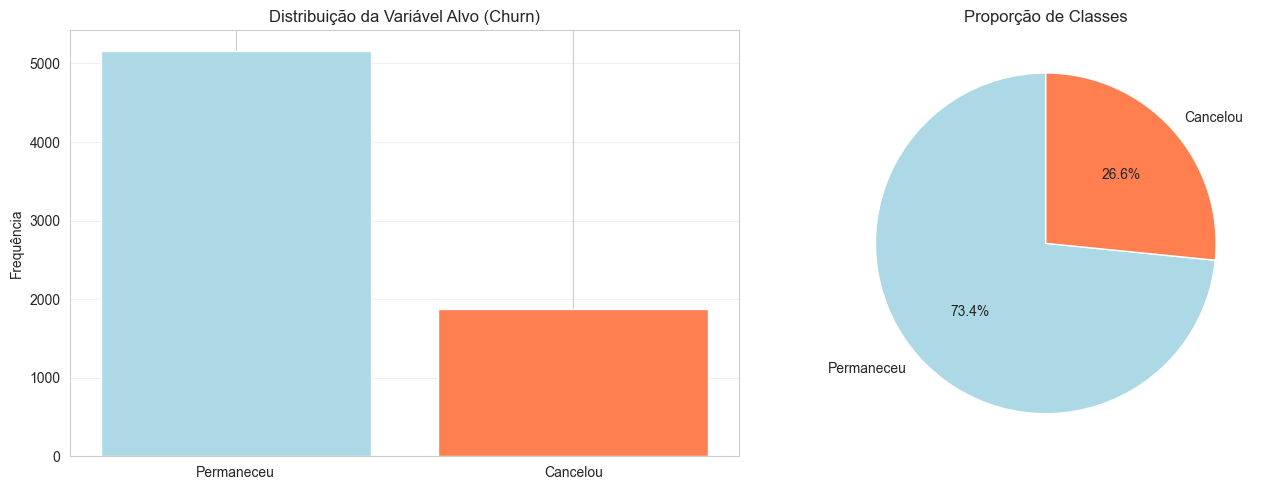


Ratio de balanceamento: 0.36
Dataset desbalanceado. Pode ser necessário usar técnicas como class_weight ou SMOTE.


In [70]:
print("=== DISTRIBUIÇÃO DA VARIÁVEL ALVO ===\n")

# -------------------------------------------------------------
# Criar tabela resumo da variável Churn
# -------------------------------------------------------------

churn_summary = (
    df["Churn"]
    .value_counts()
    .rename("Quantidade")
    .to_frame()
)

churn_summary["Percentual (%)"] = (
    df["Churn"]
    .value_counts(normalize=True) * 100
).round(2)

churn_summary = churn_summary.reset_index()
churn_summary.columns = ["Churn", "Quantidade", "Percentual (%)"]

display(churn_summary)


# -------------------------------------------------------------
# Preparar dados para gráficos
# -------------------------------------------------------------

counts = churn_summary["Quantidade"].values
labels = ["Permaneceu", "Cancelou"]


fig, axes = plt.subplots(1, 2, figsize=(14,5))

# gráfico de barras
axes[0].bar(
    labels,
    counts,
    color=["lightblue", "coral"]
)

axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da Variável Alvo (Churn)")
axes[0].grid(axis="y", alpha=0.3)


# gráfico de pizza
axes[1].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=["lightblue", "coral"],
    startangle=90
)

axes[1].set_title("Proporção de Classes")

plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# Verificação de balanceamento
# -------------------------------------------------------------

ratio = counts.min() / counts.max()

print(f"\nRatio de balanceamento: {ratio:.2f}")

if ratio < 0.5:
    print("Dataset desbalanceado. Pode ser necessário usar técnicas como class_weight ou SMOTE.")
else:
    print("✓ Dataset razoavelmente balanceado.")

A variável alvo **Churn** indica se um cliente cancelou ou permaneceu no serviço da empresa.

Observa-se que aproximadamente **73% dos clientes permanecem**, enquanto cerca de **27% cancelaram o serviço**. O ratio entre as classes é de aproximadamente **0,36**, indicando um **desbalanceamento moderado**.

Esse nível de desbalanceamento é comum em problemas de churn. Embora não seja extremo, é importante considerar métricas adicionais além da acurácia durante a avaliação dos modelos, como **precision, recall e F1-score**, além da análise da **matriz de confusão**.

Durante a etapa de modelagem, também pode ser útil utilizar **divisão estratificada dos dados** para manter a proporção de classes entre os conjuntos de treino e teste. Caso necessário, técnicas como **class_weight** ou métodos de balanceamento (por exemplo, **SMOTE**) podem ser avaliadas.

### 4.5 Distribuição das Variáveis Numéricas

Nesta etapa serão analisadas as distribuições das variáveis numéricas do dataset, com o objetivo de compreender o comportamento dos dados, identificar assimetrias, concentrações de valores e possíveis padrões relevantes.

As principais variáveis numéricas do dataset são:

- tenure
- MonthlyCharges
- TotalCharges

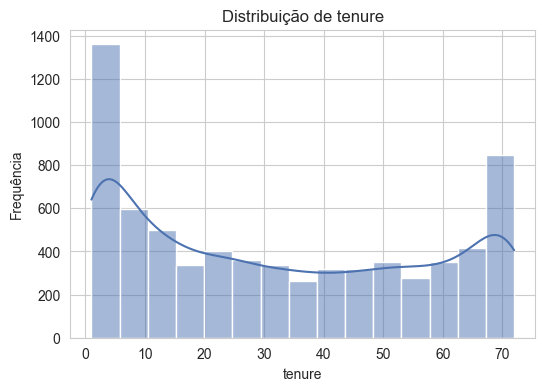

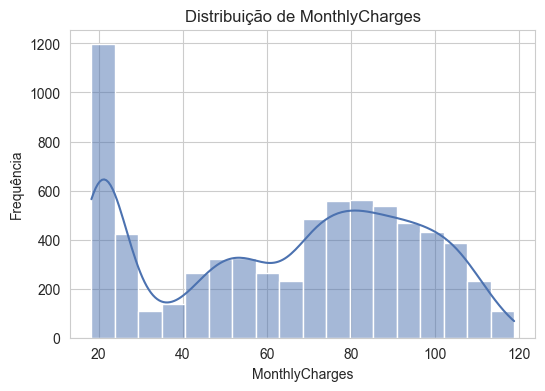

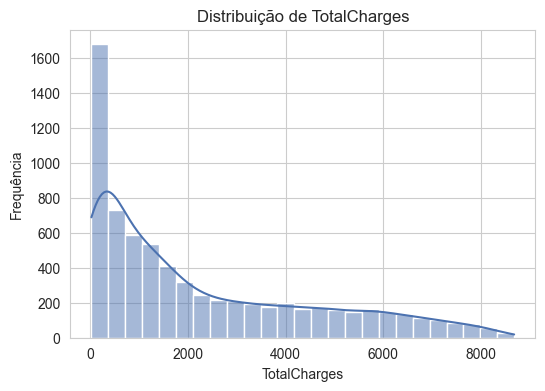

In [71]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    
    plt.show()

A variável **tenure** apresenta concentração significativa em clientes com pouco tempo de permanência, indicando que muitos clientes são relativamente novos.

A variável **MonthlyCharges** apresenta distribuição mais espalhada, refletindo diferentes níveis de serviços contratados pelos clientes.

Já **TotalCharges** apresenta assimetria à direita, comportamento esperado em variáveis acumuladas ao longo do tempo.

### 4.6 Detecção de Outliers

Nesta etapa analisamos a presença de possíveis **outliers** (valores extremos) nas variáveis numéricas do dataset.

Outliers podem indicar:

- erros de coleta de dados
- valores raros porém válidos
- comportamento extremo de clientes

A identificação de outliers foi realizada utilizando dois métodos:

- visualização por meio de boxplots
- detecção estatística utilizando o intervalo interquartil (IQR)

As variáveis numéricas analisadas são:

- tenure
- MonthlyCharges
- TotalCharges

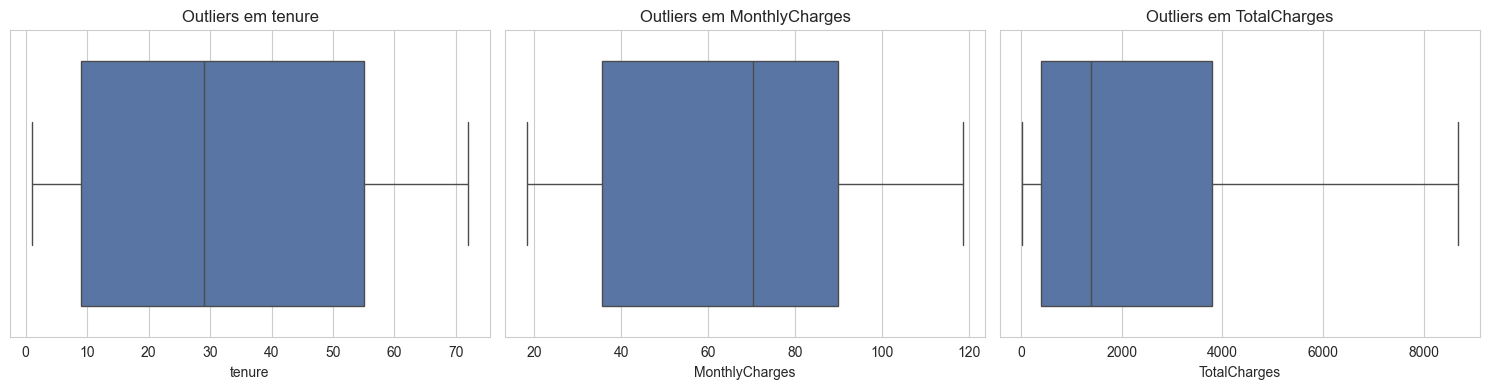


=== DETECÇÃO DE OUTLIERS (IQR) ===

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [72]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# ---------- BOX PLOTS ----------

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, col in enumerate(num_cols):
    
    sns.boxplot(x=df[col], ax=axes[i])
    
    axes[i].set_title(f"Outliers em {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()


# ---------- DETECÇÃO IQR ----------

print("\n=== DETECÇÃO DE OUTLIERS (IQR) ===\n")

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

A análise por meio de boxplots não indicou presença de outliers nas variáveis numéricas analisadas.

Isso ocorre porque os valores observados encontram-se dentro dos limites definidos pelo intervalo interquartil (IQR), sugerindo que as variações existentes são consistentes com o comportamento esperado dos dados.

Portanto, não foi necessário realizar tratamento ou remoção de outliers.

### 4.7 Relação entre Variáveis e Churn

Nesta etapa analisamos como algumas variáveis do dataset se relacionam com a variável alvo **Churn**, com o objetivo de identificar possíveis fatores associados ao cancelamento de clientes.

A análise inclui tanto variáveis **numéricas** quanto **categóricas**, permitindo observar padrões que podem ajudar na construção de modelos preditivos.

#### 4.7.1 Relação entre variáveis numéricas e churn

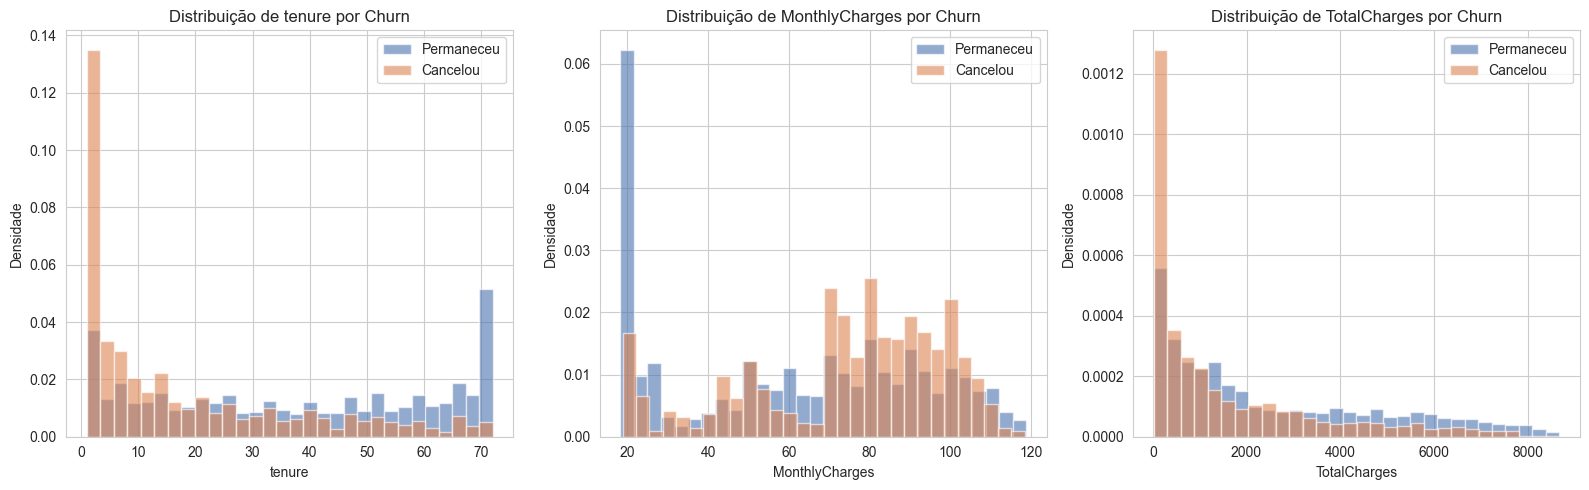

In [73]:
# -------------------------------------------------------------
# 4.7.1 Distribuição das variáveis numéricas por churn
# Comparação das distribuições de tenure, MonthlyCharges
# e TotalCharges entre clientes que cancelaram e permaneceram.
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16,5))

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for idx, col in enumerate(num_cols):

    # clientes que permaneceram
    data_no = df[df["Churn"] == "No"][col]

    # clientes que cancelaram
    data_yes = df[df["Churn"] == "Yes"][col]

    axes[idx].hist(
        data_no,
        bins=30,
        alpha=0.6,
        label="Permaneceu",
        density=True
    )

    axes[idx].hist(
        data_yes,
        bins=30,
        alpha=0.6,
        label="Cancelou",
        density=True
    )

    axes[idx].set_title(f"Distribuição de {col} por Churn")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Densidade")
    axes[idx].legend()

plt.tight_layout()
plt.show()

Observa-se que clientes com **menor tempo de permanência (tenure)** apresentam **maior incidência de churn**, indicando que o cancelamento ocorre com maior frequência nos primeiros meses de contrato.

Além disso, clientes com **mensalidades mais elevadas (MonthlyCharges)** também apresentam **maior probabilidade de cancelamento**, sugerindo que planos com custos mais altos podem influenciar a decisão de encerramento do serviço.

Por fim, clientes que cancelaram tendem a apresentar **menores valores acumulados em TotalCharges**, o que é esperado, uma vez que o total pago está diretamente relacionado ao tempo de permanência no serviço.

#### 4.7.2 Relação entre variáveis categóricas e churn

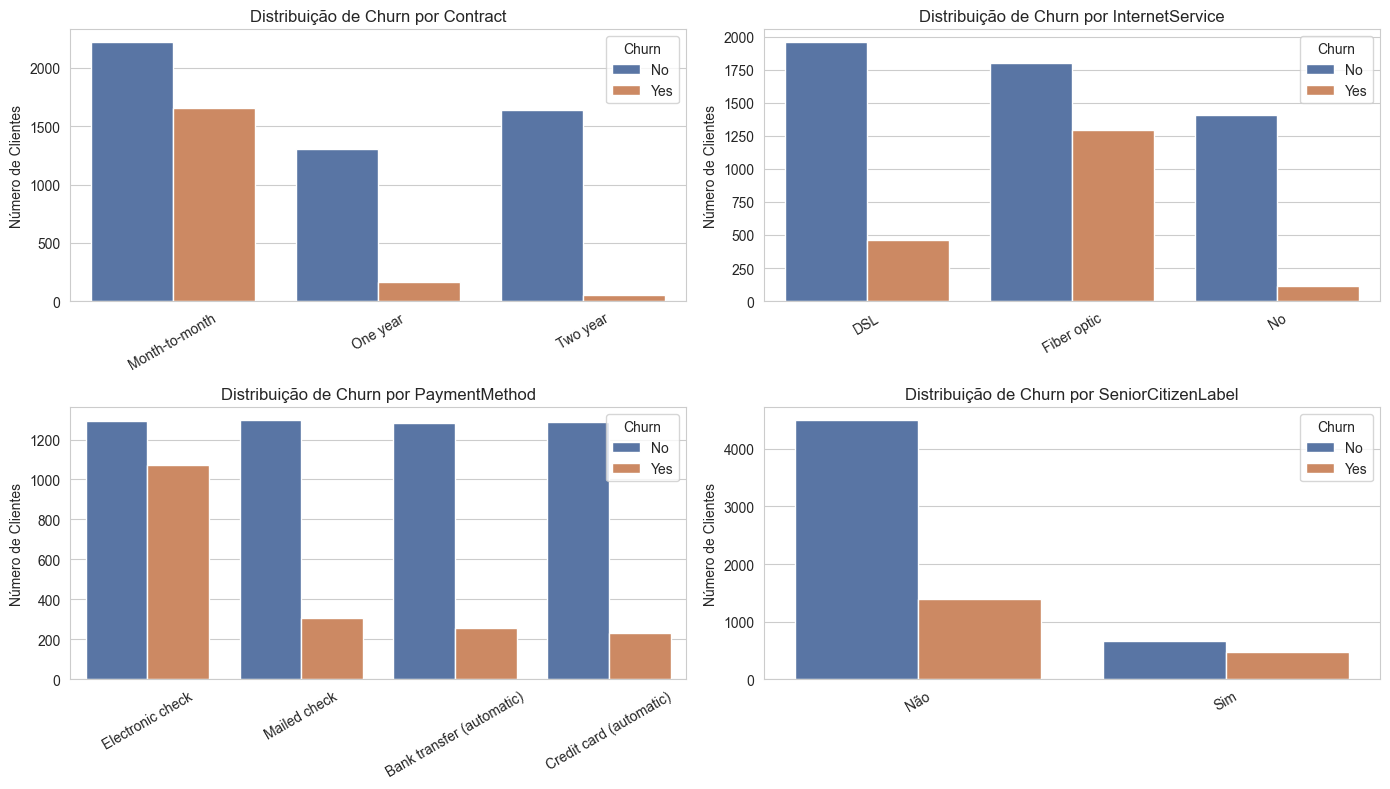

In [74]:
# -------------------------------------------------------------
# 4.7.2 Relação entre variáveis categóricas e churn
# -------------------------------------------------------------

# Criar coluna textual para SeniorCitizen
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({0: "Não", 1: "Sim"})

cat_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "SeniorCitizenLabel"
]

fig, axes = plt.subplots(2, 2, figsize=(14,8))

for i, col in enumerate(cat_cols):

    row = i // 2
    col_index = i % 2

    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        ax=axes[row][col_index]
    )

    axes[row][col_index].set_title(f"Distribuição de Churn por {col}")
    axes[row][col_index].set_xlabel("")
    axes[row][col_index].set_ylabel("Número de Clientes")
    axes[row][col_index].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Entre as variáveis categóricas, observa-se que clientes com **contratos mensais (Month-to-month)** apresentam maior incidência de churn quando comparados a contratos de longo prazo (One year e Two year), indicando que compromissos contratuais mais longos contribuem para maior retenção de clientes.

No tipo de serviço de internet, clientes que utilizam **Fiber optic** apresentam taxas de churn mais elevadas do que clientes com **DSL** ou sem serviço de internet. Esse comportamento pode estar associado a fatores como preço mais alto ou expectativas maiores em relação à qualidade do serviço.

Em relação ao método de pagamento, observa-se maior incidência de churn entre clientes que utilizam **Electronic check**, enquanto métodos de pagamento automáticos (como cartão de crédito ou transferência bancária) apresentam menor frequência de cancelamento.

Também se observa uma diferença entre clientes **SeniorCitizen**, indicando que o perfil demográfico pode ter alguma influência no comportamento de cancelamento.

#### 4.7.3 Taxa de Churn (%) por Categoria

As análises anteriores foram realizadas considerando o número de clientes, mas tal premissa pode trazer distorções, posto que uma categoria pode haver mais clientes que outras.

Desta forma, com o intuito de evitar interpretações equivocadas, surgiu o questionamento: "de todos os clientes daquela categoria, quantos cancelaram?"

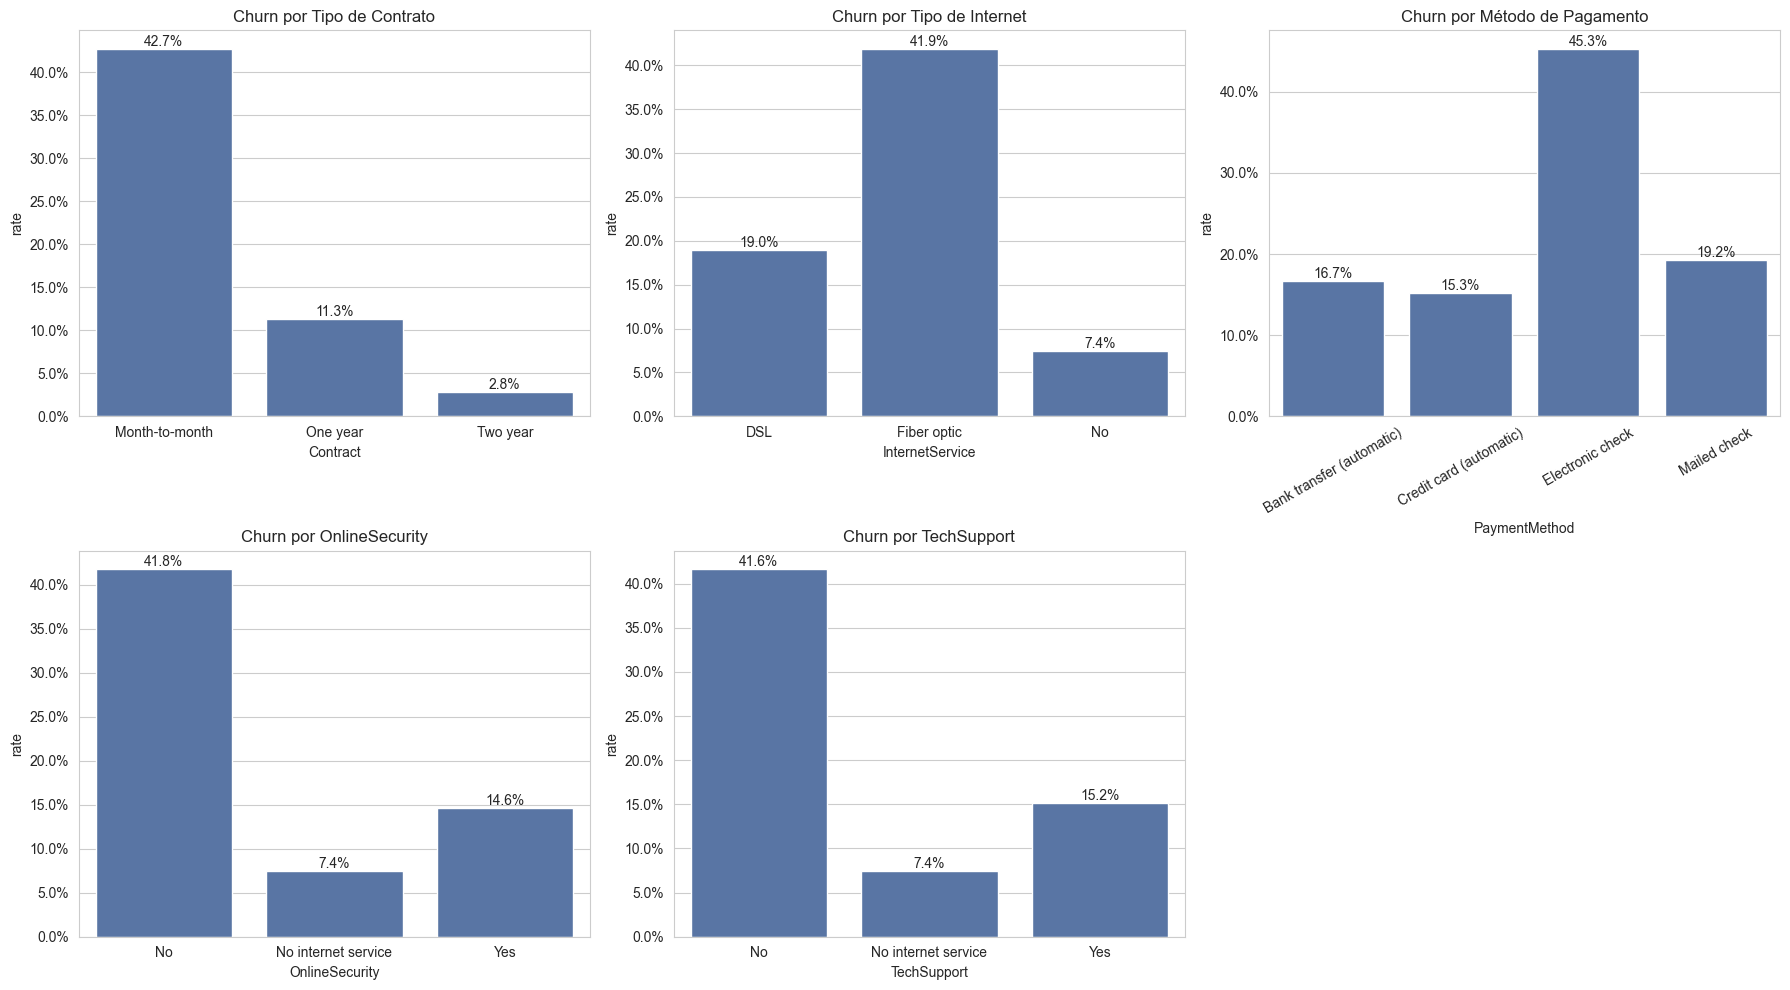

In [75]:
# -------------------------------------------------------------
# 4.7.3 Taxa de Churn (%) por Categoria
# -------------------------------------------------------------

# Função para calcular churn rate
def churn_rate_by_category(df, column):
    churn_rate = (
        df.groupby(column)["Churn"]
        .value_counts(normalize=True)
        .rename("rate")
        .reset_index()
    )
    
    return churn_rate[churn_rate["Churn"] == "Yes"]


# Função para adicionar labels nas barras
def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center',
                    va='bottom',
                    fontsize=10)


# Calcular churn rate
contract_churn = churn_rate_by_category(df, "Contract")
internet_churn = churn_rate_by_category(df, "InternetService")
payment_churn = churn_rate_by_category(df, "PaymentMethod")
security_churn = churn_rate_by_category(df, "OnlineSecurity")
techsupport_churn = churn_rate_by_category(df, "TechSupport")


# Criar painel de gráficos
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()


# ---- Contract ----
sns.barplot(data=contract_churn, x="Contract", y="rate", ax=axes[0])
axes[0].set_title("Churn por Tipo de Contrato")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
add_labels(axes[0])


# ---- InternetService ----
sns.barplot(data=internet_churn, x="InternetService", y="rate", ax=axes[1])
axes[1].set_title("Churn por Tipo de Internet")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
add_labels(axes[1])


# ---- PaymentMethod ----
sns.barplot(data=payment_churn, x="PaymentMethod", y="rate", ax=axes[2])
axes[2].set_title("Churn por Método de Pagamento")
axes[2].tick_params(axis='x', rotation=30)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
add_labels(axes[2])


# ---- OnlineSecurity ----
sns.barplot(data=security_churn, x="OnlineSecurity", y="rate", ax=axes[3])
axes[3].set_title("Churn por OnlineSecurity")
axes[3].yaxis.set_major_formatter(mtick.PercentFormatter(1))
add_labels(axes[3])


# ---- TechSupport ----
sns.barplot(data=techsupport_churn, x="TechSupport", y="rate", ax=axes[4])
axes[4].set_title("Churn por TechSupport")
axes[4].yaxis.set_major_formatter(mtick.PercentFormatter(1))
add_labels(axes[4])


# remover gráfico vazio
axes[5].axis("off")


plt.tight_layout()
plt.show()

### Análise da taxa de churn por categoria

Os gráficos apresentados mostram a **taxa de churn (%) dentro de cada categoria**, permitindo observar a probabilidade de cancelamento entre diferentes perfis de clientes.

Observa-se que clientes com contratos **Month-to-month** apresentam taxas significativamente mais elevadas de churn quando comparados a contratos de **One year** e **Two year**, indicando que contratos de longo prazo contribuem para maior retenção.

No tipo de serviço de internet, clientes que utilizam **Fiber optic** apresentam maior probabilidade de churn do que clientes com **DSL** ou sem serviço de internet. Esse comportamento pode estar relacionado a fatores como custo mais elevado do serviço ou expectativas maiores em relação à qualidade da conexão.

Em relação ao método de pagamento, clientes que utilizam **Electronic check** apresentam as maiores taxas de churn entre os métodos analisados, enquanto métodos automáticos como **credit card** e **bank transfer** apresentam menores probabilidades de cancelamento.

Esses resultados indicam que **tipo de contrato, tipo de serviço de internet e método de pagamento** são variáveis relevantes para compreender o comportamento de churn dos clientes.

#### 4.7.4 Churn Rate por Tenure (faixas de meses)

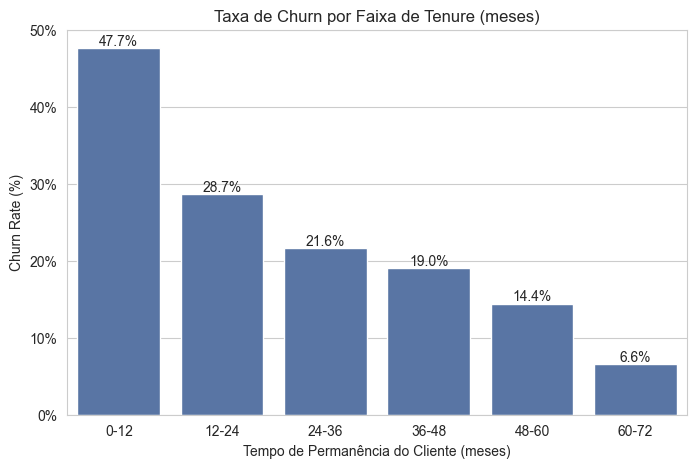

In [76]:
# -------------------------------------------------------------
# 4.7.4 Taxa de Churn por Tenure (faixas de meses)
# Analisa em que momento do ciclo de vida do cliente ocorre
# maior probabilidade de cancelamento.
# -------------------------------------------------------------

# Criar faixas de tenure
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "12-24", "24-36", "36-48", "48-60", "60-72"]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

# Calcular churn rate por faixa
tenure_churn = (
    df.groupby("tenure_group")["Churn"]
    .value_counts(normalize=True)
    .rename("rate")
    .reset_index()
)

tenure_churn = tenure_churn[tenure_churn["Churn"] == "Yes"]


plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="rate"
)

# eixo em %
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))

# adicionar labels nas barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height*100:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom')

plt.title("Taxa de Churn por Faixa de Tenure (meses)")
plt.xlabel("Tempo de Permanência do Cliente (meses)")
plt.ylabel("Churn Rate (%)")

plt.show()

### Análise da taxa de churn por tempo de permanência (tenure)

A análise por faixas de **tenure (tempo de permanência do cliente)** mostra que a probabilidade de churn é significativamente maior nos primeiros meses de relacionamento com a empresa.

Clientes com **até 12 meses de permanência** apresentam as maiores taxas de cancelamento. À medida que o tempo de permanência aumenta, observa-se uma **redução gradual da taxa de churn**.

Esse comportamento sugere que o período inicial da relação com o cliente é crítico para retenção, indicando a importância de estratégias de **onboarding, suporte inicial e fidelização** nos primeiros meses de contrato.

### 4.8 Matriz de Correlação

A matriz de correlação permite identificar relações entre as variáveis do dataset. Como grande parte das variáveis deste conjunto de dados é categórica, foi necessário realizar uma codificação numérica (encoding) antes do cálculo da correlação.

A análise da matriz de correlação auxilia na identificação de relações entre variáveis e na detecção de possíveis casos de multicolinearidade que podem impactar modelos de machine learning.

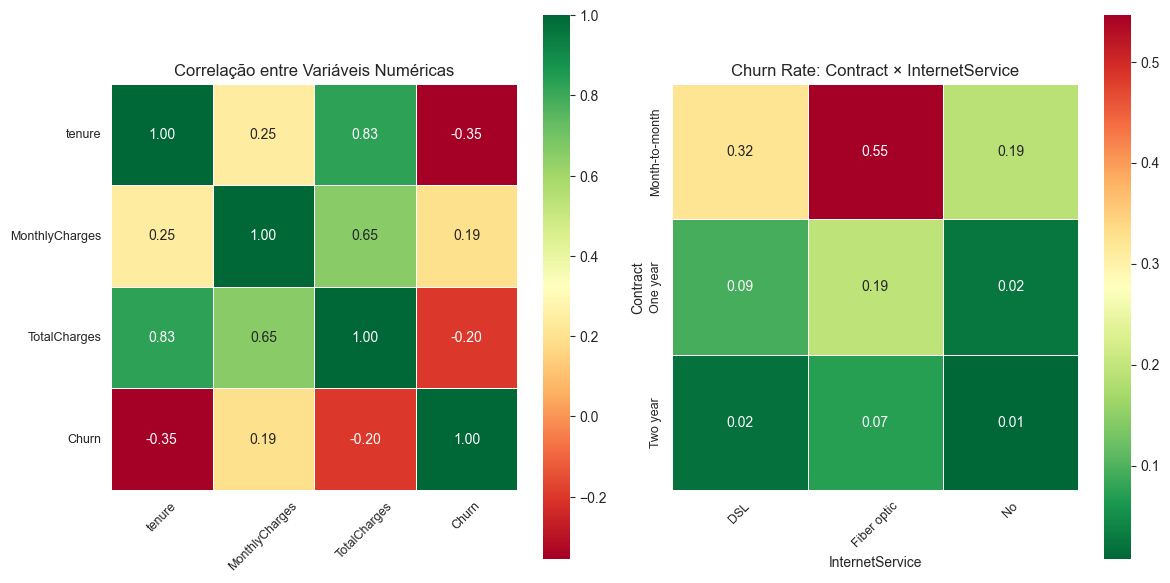

In [77]:
# -------------------------------------------------------------
# Correlação numérica e interação entre variáveis categóricas
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# =============================================================
# 1) Correlação entre variáveis numéricas
# =============================================================

df_corr = df.copy()
df_corr["Churn"] = df_corr["Churn"].map({"No":0, "Yes":1})

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr_matrix = df_corr[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    ax=axes[0],
    annot_kws={"size":10}
)

axes[0].set_title("Correlação entre Variáveis Numéricas", fontsize=12)
axes[0].tick_params(axis='x', labelsize=9, rotation=45)
axes[0].tick_params(axis='y', labelsize=9)


# =============================================================
# 2) Interação: Contract × InternetService
# =============================================================

pivot = df.pivot_table(
    values="Churn",
    index="Contract",
    columns="InternetService",
    aggfunc=lambda x: (x == "Yes").mean()
)

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn_r",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    ax=axes[1],
    annot_kws={"size":10}
)

axes[1].set_title("Churn Rate: Contract × InternetService", fontsize=12)
axes[1].tick_params(axis='x', labelsize=9, rotation=45)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

### Correlação e interação entre variáveis

A matriz de correlação mostra que **tenure apresenta correlação negativa com churn**, indicando que clientes com maior tempo de permanência tendem a cancelar menos.

Já **MonthlyCharges apresenta correlação positiva com churn**, sugerindo maior probabilidade de cancelamento entre clientes com mensalidades mais altas.

A análise de interação entre **tipo de contrato e tipo de internet** revela que clientes com contratos **month-to-month** apresentam taxas significativamente maiores de churn, especialmente quando associados ao serviço **fiber optic**.

Esse resultado reforça que **contratos de curto prazo combinados com serviços de maior custo estão mais associados ao cancelamento**.

## Principais Insights da Análise Exploratória

A análise exploratória revelou diversos fatores associados ao cancelamento dos clientes.

Observa-se inicialmente que o dataset apresenta cerca de **26% de clientes que cancelaram o serviço**, caracterizando um leve desbalanceamento entre as classes. Nesse contexto, métricas como **AUC-ROC** são mais adequadas para avaliar o desempenho dos modelos do que apenas a acurácia.

Entre as variáveis analisadas, o **tipo de contrato** mostrou-se um dos fatores mais relevantes. Clientes com contratos **month-to-month** apresentam taxas significativamente maiores de churn, enquanto contratos de maior duração, como **one year** e **two year**, apresentam níveis muito menores de cancelamento.

O **tempo de permanência do cliente (tenure)** também apresenta forte relação com churn. Clientes mais recentes possuem maior probabilidade de cancelamento, enquanto clientes com maior tempo de permanência tendem a permanecer no serviço.

Em relação aos serviços contratados, clientes com **internet fiber optic** apresentam maiores taxas de churn quando comparados aos usuários de DSL ou aos clientes sem serviço de internet.

O **método de pagamento** também demonstra influência no comportamento de churn. Clientes que utilizam **electronic check** apresentam taxas mais elevadas de cancelamento, possivelmente associadas a menor estabilidade no processo de pagamento.

Além disso, observa-se que clientes que **não utilizam serviços adicionais**, como **OnlineSecurity** ou **TechSupport**, apresentam maior probabilidade de cancelamento.

Por fim, verifica-se que a variável **TotalCharges apresenta forte correlação com tenure**, o que é esperado, uma vez que o valor total faturado tende a aumentar conforme o tempo de permanência do cliente.

## 5. Preparação para Modelagem

Após a análise exploratória, os dados precisam ser preparados para o treinamento dos modelos de machine learning.

Nesta etapa são realizadas as seguintes operações:

- separação entre variáveis preditoras (**X**) e variável alvo (**y**)
- codificação das variáveis categóricas
- divisão do dataset em conjuntos de **treino** e **teste**

A divisão treino/teste é necessária para avaliar a capacidade de generalização do modelo.  
Os dados utilizados para treinamento não devem ser os mesmos utilizados para avaliação, evitando que o modelo apenas memorize os exemplos observados.

Neste trabalho, o dataset é dividido da seguinte forma:

- **80% dos dados para treinamento**
- **20% dos dados para teste**

Além disso, utiliza-se o parâmetro **stratify**, garantindo que a proporção de churn seja mantida tanto no conjunto de treino quanto no conjunto de teste.

In [78]:
# -------------------------------------------------------------
# 5. Preparação para Modelagem
# Separação de variáveis, encoding e divisão treino/teste
# -------------------------------------------------------------

from sklearn.model_selection import train_test_split

# Converter variável alvo para formato numérico
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Remover coluna identificadora (não possui valor preditivo)
df_model = df.drop(columns=["customerID"])

# Separar variáveis preditoras (X) e variável alvo (y)
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Codificação das variáveis categóricas (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# Divisão do dataset em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Dimensão do conjunto de treino:", X_train.shape)
print("Dimensão do conjunto de teste:", X_test.shape)

Dimensão do conjunto de treino: (5625, 36)
Dimensão do conjunto de teste: (1407, 36)


## 6. Definição de Métricas

Como o problema deste projeto é uma **classificação binária** com **desbalanceamento moderado** entre as classes, a avaliação dos modelos não deve se basear apenas na acurácia.

Em cenários de churn, um modelo pode alcançar acurácia aparentemente alta apenas prevendo a classe majoritária, sem necessariamente identificar bem os clientes com risco real de cancelamento. Por isso, serão utilizadas métricas mais adequadas para esse contexto.

### Métricas técnicas

As métricas técnicas consideradas neste projeto são:

- **AUC-ROC**: mede a capacidade do modelo de distinguir clientes que irão cancelar daqueles que permanecerão. Será utilizada como **métrica principal**, por ser robusta em cenários com desbalanceamento moderado.
- **F1-score**: representa o equilíbrio entre **precision** e **recall**, sendo útil quando se deseja balancear erros de falso positivo e falso negativo.
- **Precision**: indica a proporção de clientes previstos como churn que realmente cancelaram.
- **Recall**: indica a capacidade do modelo de identificar corretamente os clientes que realmente cancelaram.
- **PR-AUC**: pode ser utilizada como métrica complementar, especialmente em cenários em que a classe positiva (churn) é de maior interesse.

### Métrica de negócio

Do ponto de vista de negócio, a métrica mais relevante é o **custo de churn evitado**.

A ideia é utilizar o modelo para identificar clientes com maior risco de cancelamento e permitir ações preventivas, como ofertas comerciais, contato proativo ou reforço de suporte.

De forma simplificada, essa métrica pode ser entendida como:

**custo de churn evitado ≈ clientes retidos × receita média mensal**

Assim, do ponto de vista operacional, métricas como **recall** ganham importância, pois identificar corretamente clientes com risco de churn pode representar preservação de receita recorrente.

In [79]:
# -------------------------------------------------------------
# 6. Definição de Métricas
# Verificação da distribuição da variável alvo
# nos conjuntos de treino e teste
# -------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

print("Métricas que serão utilizadas:")
print("- Accuracy: proporção total de acertos")
print("- F1 Score: equilíbrio entre precision e recall")
print("- Precision: entre os previstos como churn, quantos realmente cancelaram")
print("- Recall: entre os previstos como churn, quantos foram identificados corretamente")
print("- ROC-AUC (métrica principal): capacidade do modelo de distinguir churn de não churn")

# Verifica a distribuição da variável alvo nos conjuntos de treino e teste
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
test_dist = y_test.value_counts(normalize=True).sort_index() * 100

metric_context = pd.DataFrame({
    "Treino (%)": train_dist.round(2),
    "Teste (%)": test_dist.round(2)
})

metric_context.index = ["Não Churn", "Churn"]

# O objetivo é verificar se a proporção foi preservada entre os conjuntos de treino e teste
display(metric_context)

Métricas que serão utilizadas:
- Accuracy: proporção total de acertos
- F1 Score: equilíbrio entre precision e recall
- Precision: entre os previstos como churn, quantos realmente cancelaram
- Recall: entre os previstos como churn, quantos foram identificados corretamente
- ROC-AUC (métrica principal): capacidade do modelo de distinguir churn de não churn


,Treino (%),Teste (%)
Não Churn,73.42,73.42
Churn,26.58,26.58


## 7. Baseline Models

Nesta etapa são treinados modelos baseline que servirão como referência inicial para avaliar o desempenho de abordagens mais sofisticadas.

Modelos baseline são importantes porque estabelecem um ponto de comparação mínimo.  
Se um modelo mais complexo não superar o baseline, isso indica que a abordagem adotada pode não estar capturando padrões relevantes nos dados.

Neste trabalho serão utilizados dois modelos baseline:

- **DummyClassifier**: modelo simples que realiza previsões baseadas apenas na classe majoritária.
- **Regressão Logística**: modelo clássico de classificação amplamente utilizado como baseline em problemas de churn.

Os resultados serão avaliados utilizando as métricas definidas anteriormente.

In [80]:
# -------------------------------------------------------------
# 7.1 Baseline - DummyClassifier
# -------------------------------------------------------------

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_precision = precision_score(y_test, y_pred_dummy)
dummy_recall = recall_score(y_test, y_pred_dummy)

print("=== Dummy Classifier ===")
print(f"Accuracy:  {dummy_accuracy:.4f}")
print(f"F1 Score:  {dummy_f1:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall:    {dummy_recall:.4f}")

=== Dummy Classifier ===
Accuracy:  0.7342
F1 Score:  0.0000
Precision: 0.0000
Recall:    0.0000


### Interpretação dos Resultados do DummyClassifier

O **DummyClassifier** é um modelo baseline extremamente simples que realiza previsões sem considerar os atributos dos dados. No caso da estratégia `most_frequent`, o modelo sempre prevê a **classe mais frequente do dataset**.

No conjunto de dados analisado, aproximadamente **73% dos clientes não cancelaram o serviço**, enquanto cerca de **27% cancelaram**. Assim, o DummyClassifier aprende apenas a prever **sempre "não churn"**.

Por essa razão, o modelo apresenta uma **acurácia relativamente alta (~73%)**, pois acerta todos os casos da classe majoritária (ou seja, que não cancelaram o serviço). No entanto, ele **falha completamente em identificar clientes que realmente cancelaram**, resultando em valores **zero para precision, recall e F1-score**.

Esse resultado evidencia uma limitação importante da **acurácia como métrica isolada**, especialmente em problemas com **desbalanceamento de classes**. Mesmo com uma acurácia aparentemente razoável, o modelo não possui utilidade prática para o problema de churn.

Por esse motivo, métricas como **ROC-AUC, precision, recall e F1-score** são mais adequadas para avaliar o desempenho de modelos nesse tipo de cenário, pois consideram explicitamente a capacidade do modelo de identificar corretamente a classe minoritária (clientes que cancelam o serviço).

In [81]:
# -------------------------------------------------------------
# 7.2 Baseline - Regressão Logística
# -------------------------------------------------------------

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

log_accuracy = accuracy_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print("=== Logistic Regression ===")
print(f"Accuracy:  {log_accuracy:.4f}")
print(f"F1 Score:  {log_f1:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall:    {log_recall:.4f}")
print(f"ROC-AUC:   {log_auc:.4f}")

=== Logistic Regression ===
Accuracy:  0.7925
F1 Score:  0.5731
Precision: 0.6323
Recall:    0.5241
ROC-AUC:   0.8342


### Interpretação dos Resultados da Regressão Logística

A regressão logística apresentou desempenho significativamente superior ao DummyClassifier, indicando que o modelo conseguiu capturar padrões relevantes nos dados associados ao cancelamento de clientes.

A **acurácia de aproximadamente 79%** indica que o modelo classifica corretamente a maior parte das observações. No entanto, como discutido anteriormente, a acurácia isoladamente não é suficiente para avaliar modelos em cenários com desbalanceamento de classes.

A métrica **F1-score (0.57)** mostra um equilíbrio razoável entre **precision** e **recall**, indicando que o modelo consegue identificar clientes com risco de churn sem gerar um número excessivo de falsos positivos.

A **precision (0.63)** indica que, entre os clientes previstos como churn, cerca de **63% realmente cancelaram o serviço**. Já o **recall (0.52)** mostra que o modelo consegue identificar aproximadamente **52% dos clientes que efetivamente cancelaram**, o que é relevante em um cenário de retenção de clientes.

A métrica **ROC-AUC (0.83)** indica boa capacidade do modelo em distinguir entre clientes que irão cancelar e aqueles que permanecerão. Em problemas de churn, valores de ROC-AUC acima de **0.80** já são considerados bons para modelos baseline.

Comparando com o DummyClassifier, que não foi capaz de identificar nenhum cliente churn, a regressão logística demonstra capacidade real de aprendizado e estabelece um **baseline sólido para futuras melhorias e experimentos com modelos mais complexos**.

## Conclusão do EDA — Entendimento e Preparação

Nesta etapa inicial do projeto foram realizadas as atividades fundamentais para a construção do modelo de previsão de churn.

Primeiramente, foi elaborado o **ML Canvas**, permitindo estruturar o problema de negócio, identificar stakeholders e definir métricas de sucesso.

Em seguida, foi conduzida uma **Análise Exploratória de Dados (EDA)**, permitindo compreender a estrutura do dataset, avaliar a qualidade dos dados e identificar padrões associados ao cancelamento de clientes. Entre os principais fatores associados ao churn destacam-se:

- tipo de contrato
- tempo de permanência do cliente
- serviços adicionais contratados
- método de pagamento

Posteriormente, os dados foram preparados para modelagem, incluindo **codificação de variáveis categóricas e divisão em conjuntos de treino e teste**.

Por fim, foram treinados **modelos baseline**, incluindo um DummyClassifier e uma Regressão Logística. Enquanto o DummyClassifier demonstrou desempenho limitado por prever apenas a classe majoritária, a Regressão Logística apresentou resultados significativamente superiores, com **ROC-AUC de aproximadamente 0.83**, estabelecendo um baseline sólido para futuras melhorias.

Na próxima etapa, os experimentos serão **registrados e gerenciados utilizando MLflow**, permitindo rastrear parâmetros, métricas e versões de modelos.

## 8. Registro de Experimentos com MLflow

Para garantir rastreabilidade e reprodutibilidade dos experimentos, será utilizado o **MLflow**, uma ferramenta amplamente utilizada em projetos de MLOps.

O MLflow permite registrar:

- parâmetros utilizados no treinamento
- métricas de avaliação
- artefatos do modelo treinado
- versões de experimentos

Isso facilita a comparação entre diferentes abordagens e a evolução iterativa dos modelos.

In [83]:
# -------------------------------------------------------------
# 7.2 Baseline Model — Logistic Regression + MLflow
# -------------------------------------------------------------

import os
import mlflow
import mlflow.sklearn
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# garantir pasta de modelos
os.makedirs("../models", exist_ok=True)

# definir experimento
#mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("churn_prediction_baseline")

with mlflow.start_run(run_name="logistic_regression_baseline"):

    model = LogisticRegression(max_iter=1000, random_state=42)

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:,1]

    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    f1 = f1_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_prob_test)

    # parâmetros
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("dataset", "telco_customer_churn")
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("dataset_rows", len(df))

    # métricas
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("roc_auc", auc)

    # salvar modelo no MLflow
    mlflow.sklearn.log_model(model, name="model")

    print("MLflow experiment logged successfully")

    # salvar modelo local
    joblib.dump(model, "../models/logistic_regression_baseline.joblib")

2026/03/12 00:46:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow experiment logged successfully


## 9. Considerações Finais - Avaliação do Modelo

Após o treinamento da Regressão Logística, é importante avaliar o desempenho do modelo
não apenas através de métricas numéricas, mas também por meio de visualizações que
ajudam a interpretar o comportamento do classificador.

Nesta etapa são analisados três aspectos principais:

**Curva ROC (Receiver Operating Characteristic)**  
A Curva ROC mostra a relação entre a taxa de verdadeiros positivos (TPR) e a taxa de
falsos positivos (FPR) para diferentes thresholds de classificação. A área sob a curva
(AUC) indica a capacidade do modelo de distinguir clientes que irão cancelar do serviço
(churn) daqueles que permanecerão.

**Matriz de Confusão**  
A matriz de confusão apresenta os acertos e erros do modelo, mostrando quantos clientes
foram corretamente classificados como churn ou não churn, bem como os casos em que o
modelo cometeu erros de classificação.

**Interpretação das Variáveis**  
Como a regressão logística é um modelo interpretável, é possível analisar os coeficientes
associados a cada variável. Coeficientes positivos indicam aumento na probabilidade de
churn, enquanto coeficientes negativos indicam redução dessa probabilidade.

Essas análises ajudam a compreender melhor o comportamento do modelo e identificar
quais fatores estão mais associados ao cancelamento de clientes.

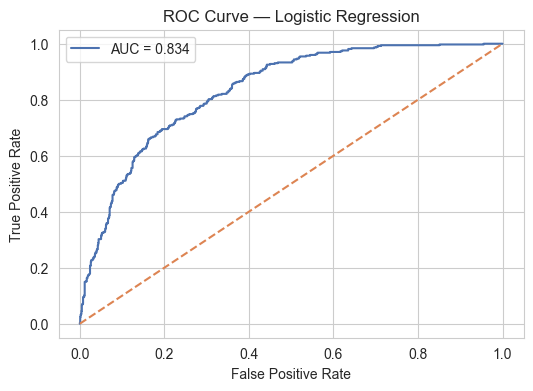

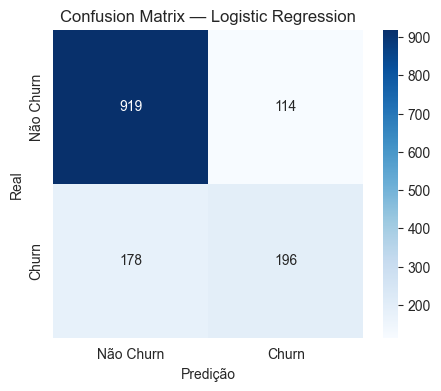

Top variáveis que aumentam a probabilidade de churn:


InternetService_Fiber optic       0.702816
tenure_group_60-72                0.486424
tenure_group_48-60                0.390919
PaymentMethod_Electronic check    0.369795
MultipleLines_Yes                 0.326027
PaperlessBilling_Yes              0.299298
StreamingTV_Yes                   0.230755
MultipleLines_No phone service    0.213795
StreamingMovies_Yes               0.207606
tenure_group_36-48                0.183743
dtype: float64

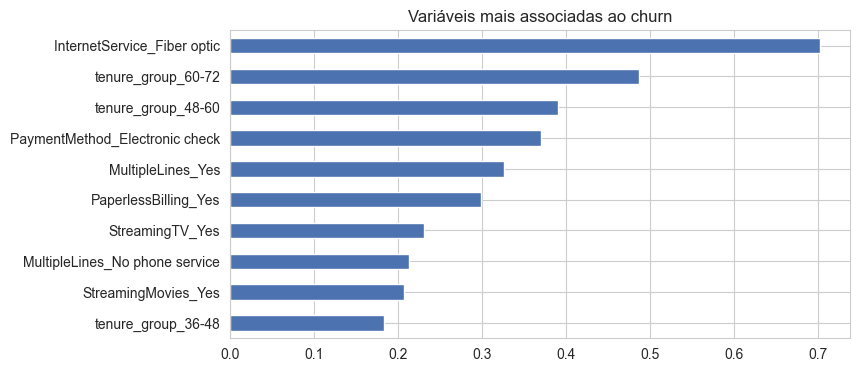

In [86]:
# -------------------------------------------------------------
# 9. Avaliação do Modelo
# ROC Curve, Confusion Matrix e interpretação das variáveis
# -------------------------------------------------------------

from sklearn.metrics import roc_curve, confusion_matrix

# =========================
# ROC Curve
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Não Churn","Churn"],
            yticklabels=["Não Churn","Churn"])

plt.xlabel("Predição")
plt.ylabel("Real")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


# =========================
# Interpretação das variáveis
# =========================

coef = pd.Series(model.coef_[0], index=X_train.columns)

print("Top variáveis que aumentam a probabilidade de churn:")
display(coef.sort_values(ascending=False).head(10))

plt.figure(figsize=(8,4))
coef.sort_values().tail(10).plot(kind="barh")
plt.title("Variáveis mais associadas ao churn")
plt.show()